<span style="color: #808080;">_I'm hoping that people reading this notebook have already seen the poster and have a general idea about the **why** behind biased splitting. The goal of these structured notebooks is to show (to the best of my abilities) **how** the idea came to be and how it was executed._</span>

# Viewing dataset as a [Molecular Network](https://www.tandfonline.com/doi/full/10.4155/fmc-2016-0023)

I hope to convey why it's useful to think of the dataset in terms of a graph / molecular network and in subsequent notebooks we will see how one can use simple graph operations to create meaningful splits. The problem we are trying to tackle here is in many ways is similar to what is commonly known as [Graph Coloring Problem](https://www-sop.inria.fr/members/Frederic.Havet/Cours/coloration.pdf), some more interesting reading can be found [here](https://stackoverflow.com/questions/39389743/how-to-check-the-graph-is-2-colorable-or-not) and [here](https://courses.cs.duke.edu/spring19/compsci230/Notes/lecture15.pdf). But for all extensive purposes, I've tried to keep this notebook self explainatory. But enough rambling, what exactly is this notebook about ?

The goals of this notebook are to:
1. Create a molecular network module that can be used throughout the project.
2. Introduce the notion of molecular network, and drawing molecular networks.
3. Introduce simple graph operation and where they might be useful.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs.cDataStructs import BulkTanimotoSimilarity

Let's randomly pick one of the datasets in the `data/standardized/`. In this case I've picked `CHEMBL1163125` which is `Bromodomain-containing protein 4`. Let's see how many molecules it has and then let's try to convert this dataframe into a molecular network.

In [2]:
df = pd.read_csv("../data/standardized/target_CHEMBL1163125-1.IC50.csv")

In [3]:
df.describe(include='all')

,assay_chembl_id,compound_chembl_id,canonical_smiles,pchembl_value,standardized_smiles
count,687,687,687,687.000000,687
unique,24,687,687,NaN,687
top,CHEMBL4733659,CHEMBL2430891,Cc1ccc2c(c1)-n1c(C)nnc1C(NC(=O)OCc1ccccc1)N=C2...,NaN,Cc1ccc2c(c1)-n1c(C)nnc1C(NC(=O)OCc1ccccc1)N=C2...
freq,42,1,1,NaN,1
mean,NaN,NaN,NaN,5.915837,NaN
std,NaN,NaN,NaN,0.979473,NaN
min,NaN,NaN,NaN,4.000000,NaN
25%,NaN,NaN,NaN,5.110000,NaN
50%,NaN,NaN,NaN,5.820000,NaN
75%,NaN,NaN,NaN,6.610000,NaN


So, we can see that all the SMILES are unique, and all the pChEMBL values, in this case pIC50 values are also unique. We can plot to see the property distribution here is something like this:

<Axes: ylabel='Frequency'>

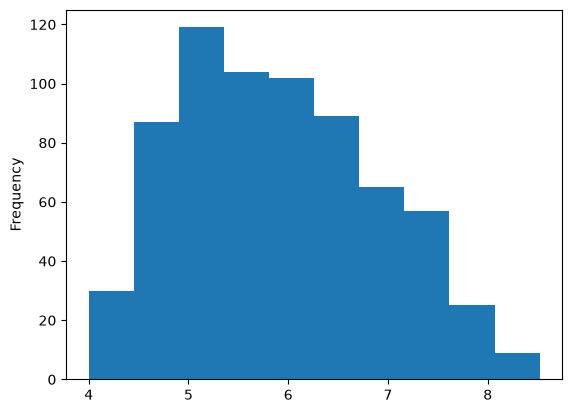

In [4]:
df['pchembl_value'].plot.hist()

Now, focusing on the goal (1. Create a molecular network module that can be used throughout the project) of this notebook, let's try to construct a function that will take parameters: dataframe, column name with standardized SMILES, column name for activity / property values. Here we assume the property of the dataset that these molecules are not $i.i.d$ and are generated while screening for one particular target so they are intrinsically related, albeit with a wide distribution of activities.
By definition this *type* of grpah is called [**Fully Connected** or **Complete** graph](https://mathworld.wolfram.com/CompleteGraph.html). 

Later on we will see why this is a bad idea and why saying all molecules are somewhat like each other is not very useful and how we can go about using [molecular similarity](https://pubs.rsc.org/en/content/articlelanding/2004/ob/b409813g) using fingerprints and distance metrics to help us get a better picture of what a molecular network should represent.

In [5]:
def df_to_fully_connected_molecular_network(df, smiles_col, activity_col):
    G = nx.Graph()

    for idx, row in df.iterrows():
        G.add_node(idx, smiles=row[smiles_col], activity=row[activity_col])

    nodes = list(df.index)
    num_nodes = len(nodes)
    
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(nodes[i], nodes[j])
            
    return G

In [6]:
G = df_to_fully_connected_molecular_network(df, 'standardized_smiles', 'pchembl_value')

In [7]:
print(G)

Graph with 687 nodes and 235641 edges


Ok, so we have a graph. Let's plot and see how it looks like.

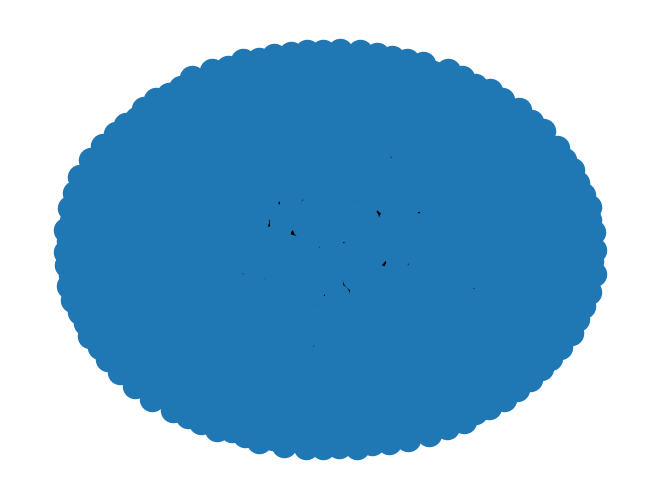

In [8]:
nx.draw(G, with_labels=False)

Yeah... That looks about as good as one would expect it to look. What's interesting to note here and it's not obvious in this layout is that this graph is fully connected. This means, each node is connected to every other node. Let's try to use a different layout so we can see this better.

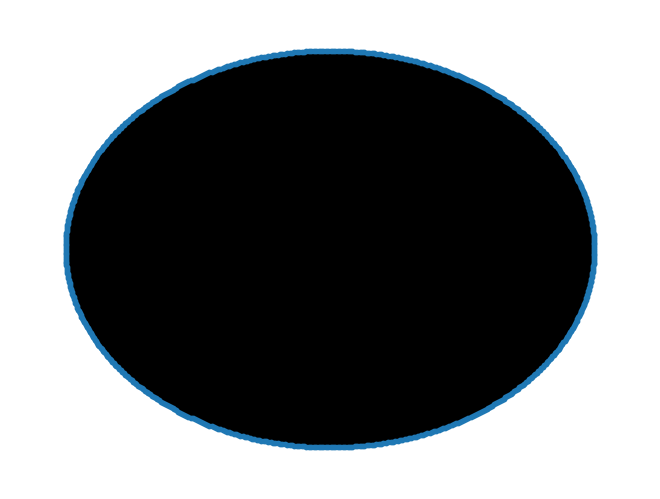

In [9]:
nx.draw(G, pos=nx.shell_layout(G), node_size=10, with_labels=False)

Right, so the black middle we see are all the edges overlapping with each other. So hopefully that's clear and it's also obvious why this is not very useful.

Now, let's do better and use molecular similarity and distance metrics to limit the number of edges. 
Here, the edges represent the similarity between two molecules. There are many ways of doing this but for the sake of simplicity and convention, I'll be using ECFP4 with Tanimoto Similarity. In subsequent notebooks, in particular for substructure distance splitting, we shall make use of Tversky Similarity, the reasons and validity for it are explained then. 
For now, we will be using [rdFingerprintGenerator](https://greglandrum.github.io/rdkit-blog/posts/2023-01-18-fingerprint-generator-tutorial.html) to generate 2048 bit ECFP4 and [BulkTanimotoSimilarity](https://www.rdkit.org/docs/source/rdkit.DataStructs.cDataStructs.html#rdkit.DataStructs.cDataStructs.BulkTanimotoSimilarity) to calculate the similarity matrix.

Tanimoto similarity is symmetric meaning $\text{Tanimoto}(A, B) = \text{Tanimoto}(B, A)$. This property allows us to reduce the computation of similarity matrix by half as we can derive the lower triangle of matrix from upper triangle.

The last point of order that differentiates what we are about to build from the previous implementation is that we are going to parameterise the function with dataframe, column name with standardized SMILES, column name for activity / property values and similarity threshold which is a float between [0,1]. Similarity threshold works as a rectifier on Tanimoto similarity between nodes. If the similarity is less than the threshold, the edge is removed (or never created in the first place). If the similarity is greater than the similarity threshold, then the edge weight is set to the similarity between nodes. We shall shortly see why weighing edges is useful.

In [10]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [11]:
def smiles_to_ecfp4_bitvect(smi): 
    return mfpgen.GetFingerprint(Chem.MolFromSmiles(smi))

In [12]:
fps_bitvect = df['standardized_smiles'].apply(smiles_to_ecfp4_bitvect).values

In [13]:
fps_bitvect

array([<rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x1122feb20>,
      dtype=object)

Just to see if we are on the right track, let's try to plot these fps. For this instead of creating fp as `ExplicitBitVect` object, we will use `GetFingerprintAsNumPy` method.

In [14]:
def smiles_to_ecfp4_np(smi): 
    return mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi))

In [15]:
fps_np = np.vstack(df['standardized_smiles'].apply(smiles_to_ecfp4_np).values)

In [16]:
fps_np

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(687, 2048), dtype=uint8)

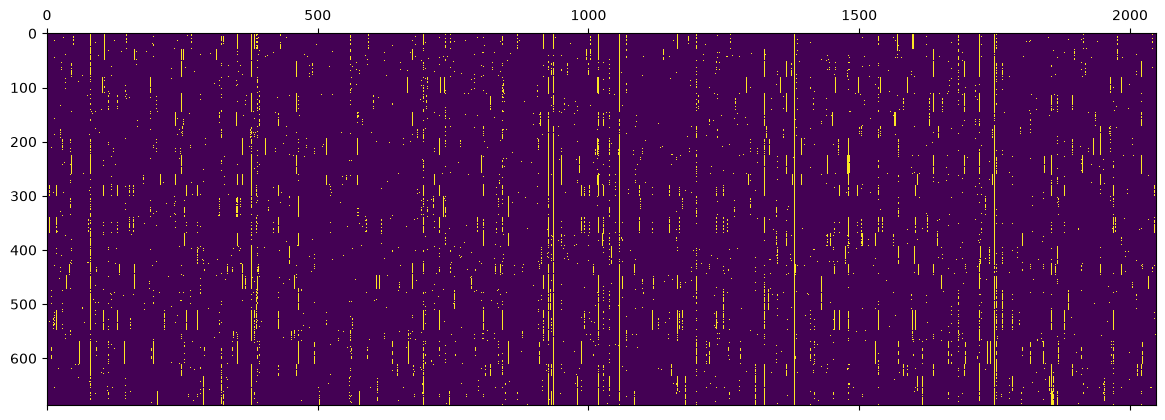

In [17]:
plt.matshow(fps_np)

Great so fingerprints work. Now let's get the similarity matrix to work. To use `BulkTanimotoSimilarity`, we need the fingerprints to be `ExplicitBitVect`, `SparseBitVect`, etc. i.e. we won't use the `fps_np` here.

In [18]:
def compute_similarity_matrix(fps_bitvect):
    n = len(fps_bitvect)
    sim_matrix = np.eye(n, dtype=np.float32)

    for i in range(n - 1): # Remember symmetrical matrix !
        sims = BulkTanimotoSimilarity(fps_bitvect[i], fps_bitvect[i+1:])
        sim_matrix[i, i+1:] = sims
        sim_matrix[i+1:, i] = sims
        
    return sim_matrix

In [19]:
similarity_matrix = compute_similarity_matrix(fps_bitvect)

In [20]:
similarity_matrix

array([[1.        , 0.33695653, 0.8305085 , ..., 0.11650486, 0.10784314,
        0.13861386],
       [0.33695653, 1.        , 0.35227272, ..., 0.16666667, 0.14814815,
        0.1559633 ],
       [0.8305085 , 0.35227272, 1.        , ..., 0.0990099 , 0.1122449 ,
        0.11      ],
       ...,
       [0.11650486, 0.16666667, 0.0990099 , ..., 1.        , 0.45      ,
        0.475     ],
       [0.10784314, 0.14814815, 0.1122449 , ..., 0.45      , 1.        ,
        0.7058824 ],
       [0.13861386, 0.1559633 , 0.11      , ..., 0.475     , 0.7058824 ,
        1.        ]], shape=(687, 687), dtype=float32)

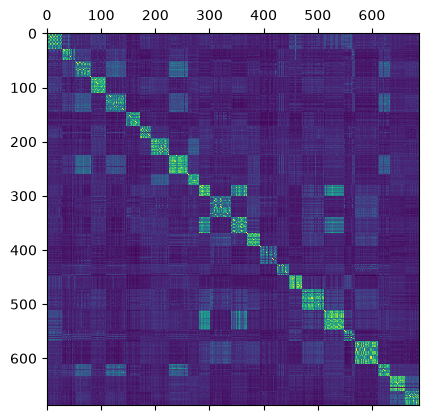

In [21]:
plt.matshow(similarity_matrix)

Amazing, let's see the distribution of the similarity wrt number of molecule pairs.

In [22]:
upper_tri_indices = np.triu_indices_from(similarity_matrix, k=1)
unique_similarities = similarity_matrix[upper_tri_indices]
unique_similarities

array([0.33695653, 0.8305085 , 0.7205882 , ..., 0.45      , 0.475     ,
       0.7058824 ], shape=(235641,), dtype=float32)

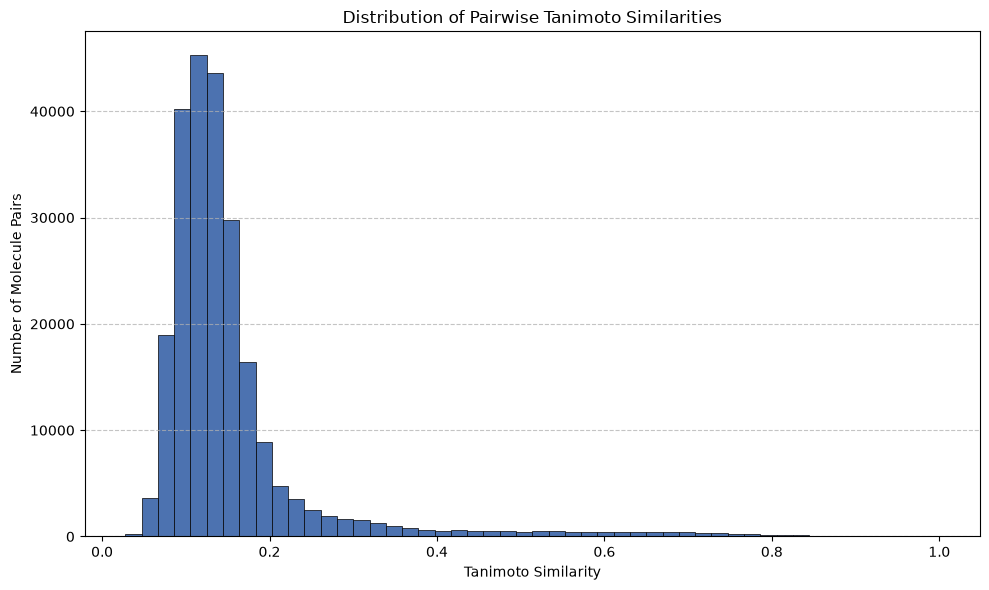

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(unique_similarities, bins=50, color='#4C72B0', edgecolor='black', linewidth=0.5)
plt.title('Distribution of Pairwise Tanimoto Similarities')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Number of Molecule Pairs')
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.tight_layout()
plt.show()

Right, this makes sense, most molecules are not very similar to each other and very few are highly selective.

Ok, so now let's combine everything and combine the molecular network that actually represents all this abovementioned data.

In [24]:
def df_to_ecfp4_molecular_network(df, smiles_col, activity_col, similarity_threshold, activity_threshold):
    fps_bitvect = df[smiles_col].map(smiles_to_ecfp4_bitvect).tolist()
    sim_matrix = compute_similarity_matrix(fps_bitvect)

    adj_matrix = np.triu(sim_matrix, k=1)
    adj_matrix[adj_matrix < similarity_threshold] = 0
    G = nx.from_numpy_array(adj_matrix)

    node_attrs = {
        n: {'smiles': smi, 'activity': act} 
        for n, (smi, act) in enumerate(zip(df[smiles_col], df[activity_col]))
    }
    nx.set_node_attributes(G, node_attrs)
    G.graph['activity_label'] = activity_col
    G.graph['activity_threshold'] = activity_threshold
    G.graph['similarity_threshold'] = similarity_threshold
    G.graph['similarity_fp'] = '2048bit ECFP4'
    G.graph['similarity_distance'] = 'Tanimoto'
    return G

In [25]:
G = df_to_ecfp4_molecular_network(df, 'standardized_smiles', 'pchembl_value', similarity_threshold=0.8, activity_threshold=1)

In [26]:
print(G)

Graph with 687 nodes and 536 edges


Even before plotting the difference is clear:

- Molecular Network **Without** Similarity Threshold : `687 nodes and 235641 edges`
- Molecular Network **With** Similarity Threshold (0.7) : `687 nodes and 536 edges`

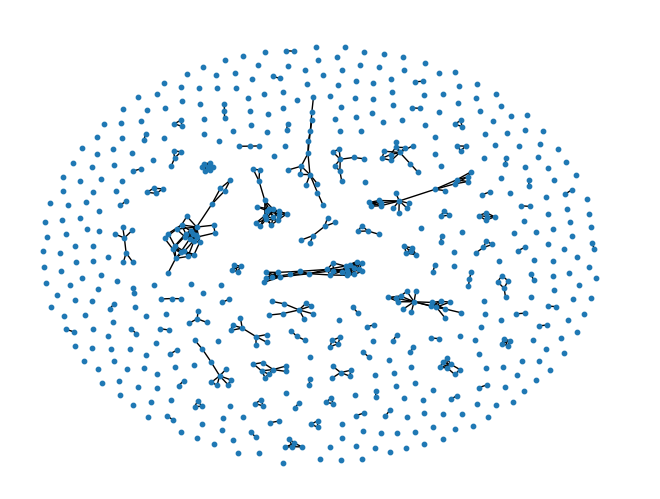

In [27]:
nx.draw(G, pos=nx.spring_layout(G), node_size=10, with_labels=False)

Isn't that interesting !

Obvious next question is how does number of edges change with change in similarity threshold for this target ?
Let's plot this.

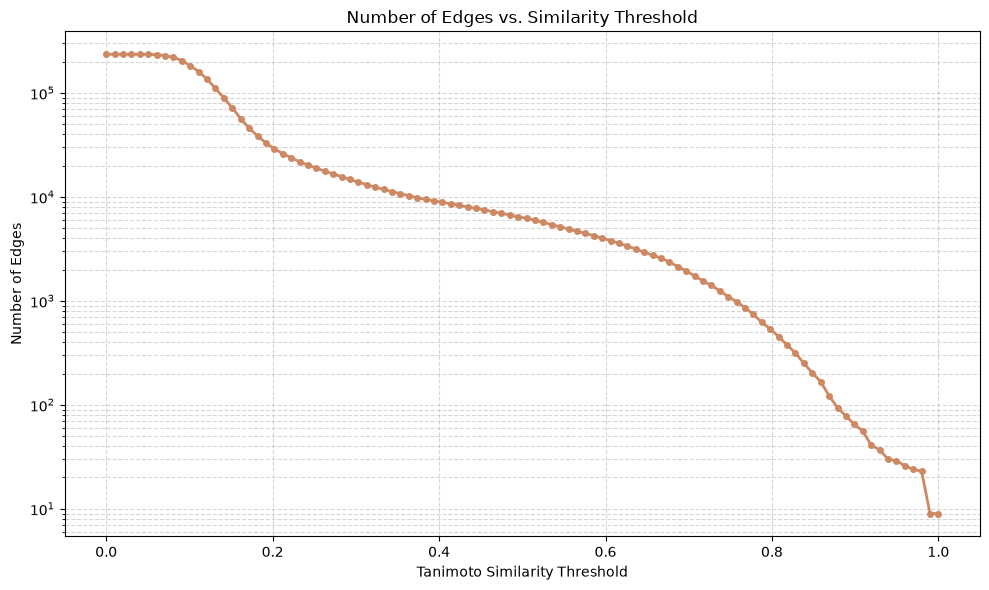

In [28]:
unique_similarities = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
thresholds = np.linspace(0.0, 1.0, 100)
edge_counts = [np.sum(unique_similarities >= t) for t in thresholds]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, edge_counts, color='#CC8963', linewidth=2, marker='o', markersize=4)
plt.title('Number of Edges vs. Similarity Threshold')
plt.xlabel('Tanimoto Similarity Threshold')
plt.ylabel('Number of Edges')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

OK, now let's try to tackle goal 3. Introduce simple graph operation and where they might be useful

Some common operations we would like to do with this molecular network are:

**1. Removing node**

Let's try removing node #67. First we will see what it's connected to and then we happens

In [29]:
print(G.nodes[67])
G[67]

{'smiles': 'Cc1noc(C)c1-c1ccc2c(c1)C(OCCCN1CCOCC1)CC2', 'activity': 5.2}


AtlasView({54: {'weight': 0.8392857313156128}, 60: {'weight': 0.8545454740524292}, 62: {'weight': 0.8103448152542114}})

In [30]:
G.remove_node(67)

In [31]:
G.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,

So, the node is gone.

**2. Get node degree**

This will come in super handy in subsequent notebooks

In [32]:
G[176]

AtlasView({181: {'weight': 0.8367347121238708}, 185: {'weight': 0.807692289352417}})

In [33]:
G.degree(176)

2

**3. Get entire connected component**

This will be very useful for notebook where we implement substructure distance split.

In [34]:
sorted(list(nx.connected_components(G)), key=len, reverse=True)

[{513,
  514,
  515,
  517,
  518,
  519,
  520,
  521,
  522,
  523,
  524,
  525,
  527,
  528,
  529,
  530,
  531,
  532,
  533,
  535,
  536,
  537,
  539,
  540,
  541,
  542,
  543,
  544,
  548},
 {570,
  571,
  573,
  575,
  576,
  578,
  581,
  585,
  587,
  588,
  589,
  590,
  591,
  593,
  594,
  598,
  601,
  602,
  603,
  604,
  605,
  606,
  607,
  608,
  610},
 {281,
  282,
  284,
  285,
  287,
  290,
  291,
  292,
  293,
  297,
  298,
  299,
  300,
  349,
  350,
  356,
  365,
  368},
 {634,
  635,
  636,
  637,
  641,
  642,
  643,
  644,
  645,
  649,
  650,
  651,
  652,
  653,
  656,
  657,
  658,
  659},
 {226,
  228,
  229,
  232,
  233,
  234,
  235,
  240,
  243,
  244,
  245,
  247,
  249,
  253,
  255,
  256,
  257},
 {82, 83, 88, 89, 91, 93, 95, 98, 99, 101, 103, 105, 106, 109},
 {0, 2, 3, 4, 5, 9, 10, 16, 17, 27, 28},
 {193, 195, 196, 199, 200, 202, 203, 214, 219},
 {613, 615, 616, 627, 628, 629, 630, 631, 632},
 {173, 175, 177, 178, 179, 184, 190, 192},
 {

**4. Get/Set node attributes**

In [35]:
G.nodes[0]

{'smiles': 'Cc1ccc2c(c1)-n1c(C)nnc1C(NC(=O)OCc1ccccc1)N=C2c1ccccc1',
 'activity': 5.8}

In [36]:
G.nodes[0]['activity'] = 5.81

In [37]:
G.nodes[0]

{'smiles': 'Cc1ccc2c(c1)-n1c(C)nnc1C(NC(=O)OCc1ccccc1)N=C2c1ccccc1',
 'activity': 5.81}

**5. Get/Set edge attributes**

In [38]:
G.edges[528,542]

{'weight': 0.8085106611251831}

In [39]:
G.edges[528,542]['weight'] = 0.8

In [40]:
G.edges[528,542]

{'weight': 0.8}

### Let's visualise this clearly

Let's use pygraphviz with neato layout to plot our molecular network

In [41]:
def visualise_molnet(G, filepath=None):
    fig, ax = plt.subplots(figsize=(12, 9))
    
    pos = nx.nx_agraph.graphviz_layout(G, prog="neato")

    edge_colors = []
    for u, v in G.edges():
        if abs(G.nodes[u]["activity"] - G.nodes[v]["activity"]) > G.graph['activity_threshold']:
            edge_colors.append((1, 0, 0, 1))
        else:
            w = G.edges[u, v]["weight"]
            edge_colors.append((1 - w, 1 - w, 1 - w, 0.6))
    
    node_colors = [G.nodes[n]["activity"] for n in G.nodes()]
    
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=0.8, ax=ax)
    nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.Greys,
                                    node_size=40, linewidths=0, ax=ax)
    
    cbar = fig.colorbar(nodes, ax=ax)
    cbar.set_label(G.graph['activity_label'])
    ax.axis("off")
    plt.title(f"Molecular Network with {G.number_of_nodes()} molecules & {G.number_of_edges()} edges made using \nSimilarity Threshold of {G.graph['similarity_threshold']} over {G.graph['similarity_fp']} fingerprints using {G.graph['similarity_distance']} Similarity")
    if filepath:
        plt.tight_layout()
        plt.savefig(filepath)
    plt.show()

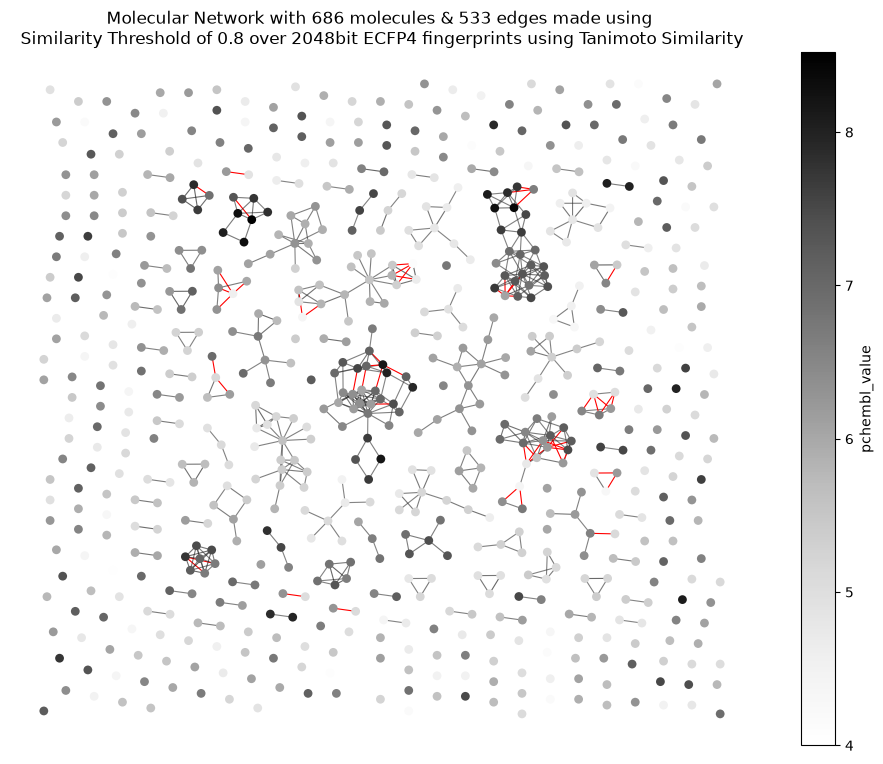

In [42]:
visualise_molnet(G)